# Random Forest Importance Expanded


In [1]:
import sys
from pathlib import Path

_here = Path().resolve()
REPO_ROOT = _here
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "src" / "stroke_data.py").is_file():
        break
    REPO_ROOT = REPO_ROOT.parent
else:
    raise FileNotFoundError("Could not find src/stroke_data.py (open this project from the repo folder).")

sys.path.insert(0, str(REPO_ROOT / "src"))

## Imports


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

from stroke_data import get_stroke_data_for_cv


## Data And Configuration


In [3]:
CSV = "data/knn-standardize-distance.csv"
OUT = "src/feature_selection/feature_importance_rf.csv"
TOP_K_CANDIDATES = [3, 5, 8, 10]

csv_path = REPO_ROOT / CSV
df = pd.read_csv(csv_path)
feature_names = [c for c in df.columns if c not in ("id", "stroke")]

X_train, X_test, y_train, y_test = get_stroke_data_for_cv(str(csv_path))
len(feature_names), X_train.shape


(10, (4088, 10))

## Train Random Forest Selector


In [4]:
rf_sel = RandomForestClassifier(
    bootstrap=False, 
    class_weight='balanced_subsample', 
    max_depth=None, 
    max_features=None, 
    max_leaf_nodes=None, 
    n_estimators=15
)

rf_sel.fit(X_train, y_train)

imp = rf_sel.feature_importances_
order = np.argsort(imp)[::-1]

out_df = pd.DataFrame({
    "feature": [feature_names[i] for i in order],
    "importance": imp[order],
    "rank": range(1, len(feature_names) + 1),
})
out_df["importance_pct"] = (out_df["importance"] * 100).round(2)
out_df["cumsum_pct"] = (out_df["importance"].cumsum() * 100).round(1)

out_df[["rank", "feature", "importance", "importance_pct", "cumsum_pct"]].style.format({
    "importance": "{:.4f}",
    "importance_pct": "{:.2f}%",
    "cumsum_pct": "{:.1f}%",
}).hide(axis="index")


rank,feature,importance,importance_pct,cumsum_pct
1,age,0.4977,49.77%,49.8%
2,avg_glucose_level,0.1957,19.57%,69.3%
3,bmi,0.1950,19.50%,88.8%
4,smoking_status,0.0346,3.46%,92.3%
5,work_type,0.0215,2.15%,94.5%
6,Residence_type,0.0172,1.72%,96.2%
7,ever_married,0.0128,1.28%,97.5%
8,gender,0.0100,1.00%,98.5%
9,heart_disease,0.0086,0.86%,99.3%
10,hypertension,0.0069,0.69%,100.0%


## Save Importance Ranking


In [5]:
out_path = REPO_ROOT / OUT
out_path.parent.mkdir(parents=True, exist_ok=True)
out_df[["feature", "importance", "rank"]].to_csv(out_path, index=False)
out_path


PosixPath('/Users/emilyweiss/Desktop/Stroke-Prediction-ML/src/feature_selection/feature_importance_rf.csv')

## Importance Plot


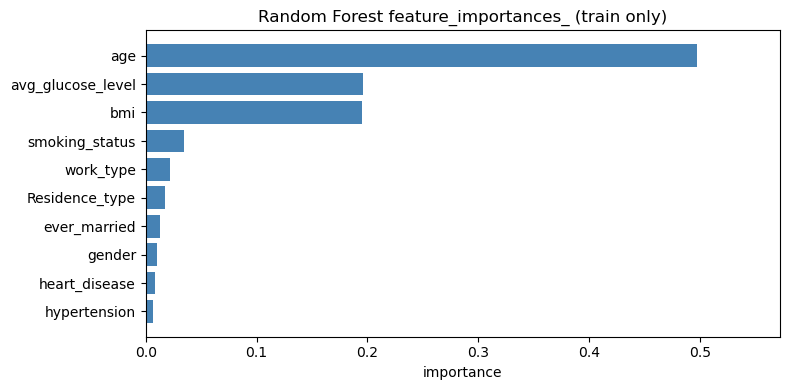

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(out_df["feature"][::-1], out_df["importance"][::-1], color="steelblue")
ax.set_xlabel("importance")
ax.set_title("Random Forest feature_importances_ (train only)")
ax.set_xlim(0, max(out_df["importance"]) * 1.15)
plt.tight_layout()
